In [1]:
# 1. 库导入及相关设置
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate as tb
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


In [2]:
# 2. 设置文件路径
input_path = 'C:/Users/dddai/Downloads/user_personalized_features.csv'
output_dir = 'C:/Users/dddai/Downloads/user segment'

In [3]:
# 3. 数据加载与预处理
def load_and_preprocess(filepath):
    df = pd.read_csv(filepath, index_col = 0)
    print("第一部分：数据预处理\n")
    
    print(f"数据规模: {df.shape[0]} 行 x {df.shape[1]} 列")
    print(f"缺失值: {df.isna().sum().sum()}")
    print(f"重复值: {df.duplicated().sum()}")
    age_outliers = df[(df['Age'] < 10) | (df['Age'] > 100)].shape[0]
    print(f"年龄异常值: {age_outliers}")    
    return df

df = load_and_preprocess(input_path)
df.head()


第一部分：数据预处理

数据规模: 1000 行 x 14 列
缺失值: 0
重复值: 0
年龄异常值: 0


,User_ID,Age,Gender,Location,Income,Interests,Last_Login_Days_Ago,Purchase_Frequency,Average_Order_Value,Total_Spending,Product_Category_Preference,Time_Spent_on_Site_Minutes,Pages_Viewed,Newsletter_Subscription
0,#1,56,Male,Suburban,38037,Sports,5,7,18,2546,Books,584,38,True
1,#2,46,Female,Rural,103986,Technology,15,7,118,320,Electronics,432,40,False
2,#3,32,Female,Suburban,101942,Sports,28,1,146,3766,Apparel,306,1,True
3,#4,60,Female,Suburban,71612,Fashion,18,3,163,4377,Apparel,527,29,False
4,#5,25,Male,Suburban,49725,Travel,2,5,141,4502,Health & Beauty,53,10,True


In [4]:
# 4. 构建RFM模型所需指标及优化指标
def feature_engineering(df):
    
    print("第二部分：指标构建\n")

    # 1. I_Score 意向度 Friction 决策难度系数
    def min_max_normalize(series, reverse=False):
        min_val, max_val = series.min(), series.max()
        if max_val == min_val:
            return pd.Series([50] * len(series))
        if reverse:
            return ((max_val - series) / (max_val - min_val)) * 100
        return ((series - min_val) / (max_val - min_val)) * 100
    
    df['Time_Spent_Norm'] = min_max_normalize(df['Time_Spent_on_Site_Minutes'])
    df['Pages_Viewed_Norm'] = min_max_normalize(df['Pages_Viewed'])
    df['I_Score'] = 0.5 * df['Time_Spent_Norm'] + 0.5 * df['Pages_Viewed_Norm']
    
    # 2. Income 收入分层
    income_33 = df['Income'].quantile(0.33)
    income_66 = df['Income'].quantile(0.66)
    df['Income_Level'] = pd.cut(
        df['Income'], 
        bins = [-float('inf'), income_33, income_66, float('inf')], 
        labels = ['Low', 'Medium', 'High'])


    # 3. 指标范围
    print(f"I_Score 范围: [{df['I_Score'].min():.2f}, {df['I_Score'].max():.2f}]")
    print(f"Income_Level 分布: {df['Income_Level'].value_counts().to_dict()}")

    return df

df = feature_engineering(df)
df[['User_ID','I_Score','Income_Level']].head()

第二部分：指标构建

I_Score 范围: [0.00, 98.83]
Income_Level 分布: {'High': 340, 'Low': 330, 'Medium': 330}


,User_ID,I_Score,Income_Level
0,#1,87.285385,Low
1,#2,76.638400,High
2,#3,25.460637,High
3,#4,73.136516,Medium
4,#5,13.646357,Low


第三部分：探索性数据分析


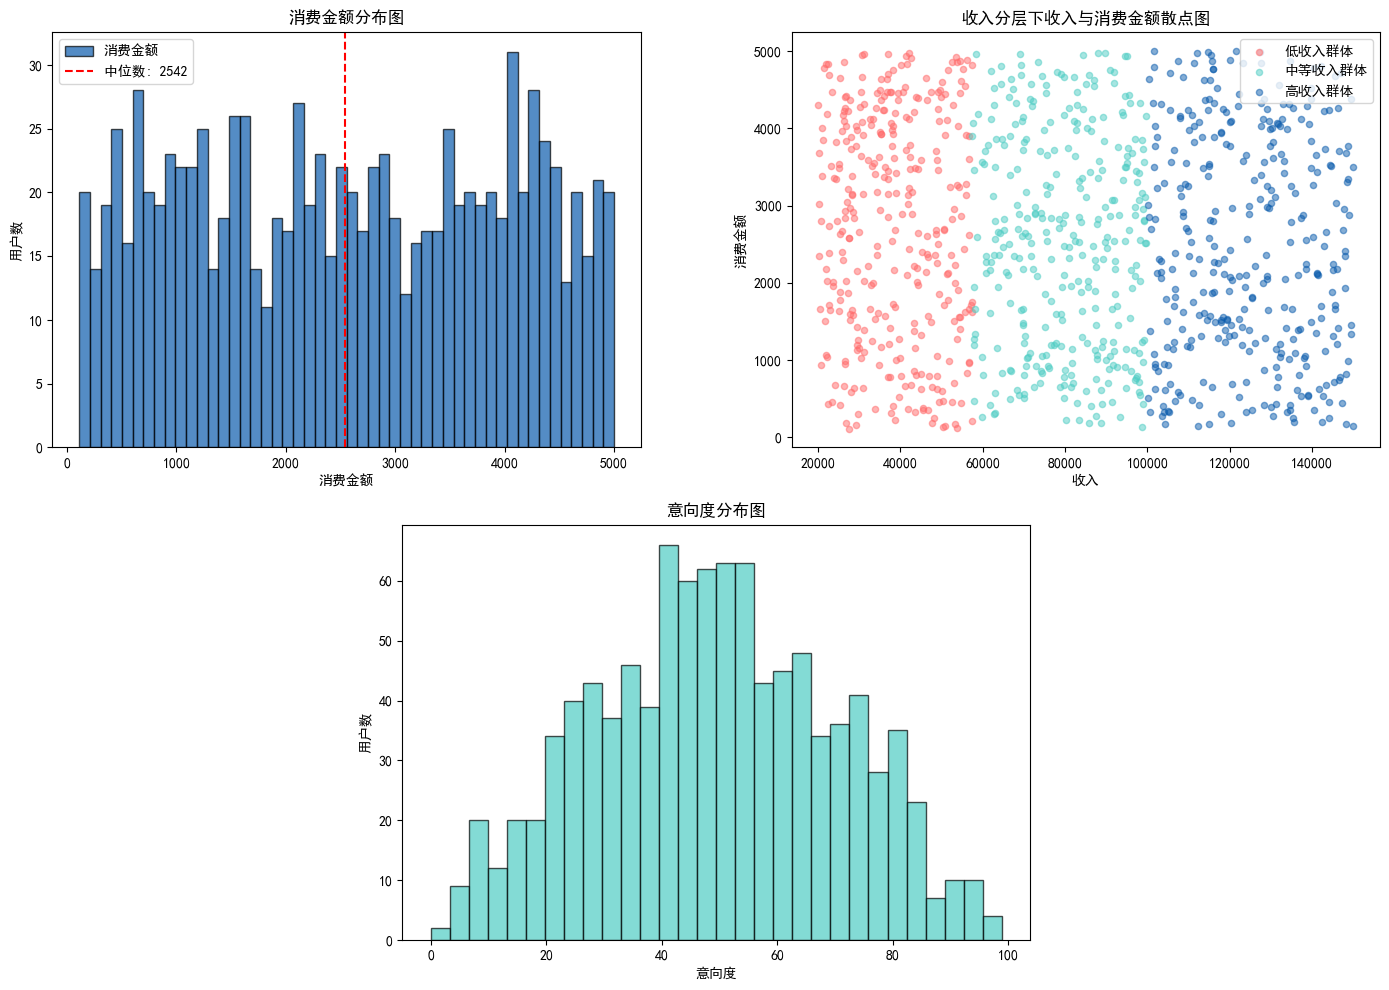

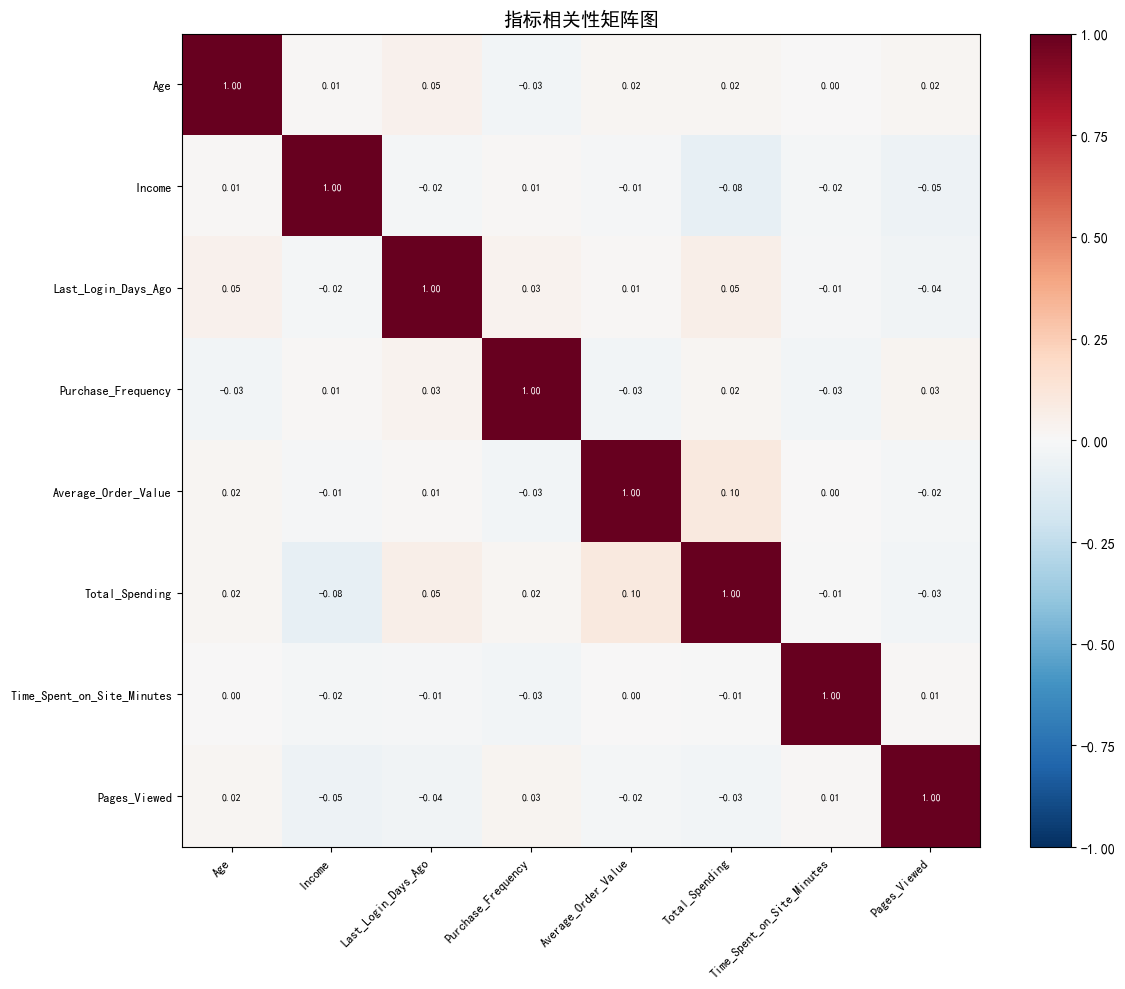


关键相关性分析:
网站停留时间 vs 购买频率相关系数: -0.028
访问页数 vs 购买频率相关系数: 0.026
网站停留时间 vs 消费金额相关系数: -0.006
访问页数 vs 消费金额相关系数: -0.029

高收入低消费群体:
  - 用户数: 184
  - 占高收入群体比例: 54.1%


In [5]:
# 5. 探索性数据分析
def perform_eda(df, output_dir):

    print("第三部分：探索性数据分析")

    
    # 1. 指标分布分析
    #fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig = plt.figure(figsize=(14, 10))
    
    # Total_Spending 消费金额分布
    ax1 = plt.subplot2grid((2, 2), (0, 0))
    ax1.hist(df['Total_Spending'], bins=50, edgecolor='black', alpha=0.7, color='#0B5CAD', label='消费金额')
    ax1.set_title('消费金额分布图', fontsize=12)
    ax1.set_xlabel('消费金额')
    ax1.set_ylabel('用户数')
    ax1.axvline(df['Total_Spending'].median(), color='red', linestyle='--', 
                       label=f'中位数: {df["Total_Spending"].median():.0f}')
    ax1.legend()

    
    # Income vs Total_Spending 散点图
    ax2 = plt.subplot2grid((2, 2), (0, 1))
    colors = {'Low': '#FF6B6B', 'Medium': '#4ECDC4', 'High': '#0B5CAD'}
    labelnames = {
    'Low': '低收入群体',
    'Medium': '中等收入群体',
    'High': '高收入群体'
    }
    for level in ['Low', 'Medium', 'High']:
        subset = df[df['Income_Level'] == level]
        ax2.scatter(subset['Income'], subset['Total_Spending'], 
                          alpha=0.5, label=labelnames[level], c=colors[level], s=20)
    ax2.set_title('收入分层下收入与消费金额散点图', fontsize=12)
    ax2.set_xlabel('收入')
    ax2.set_ylabel('消费金额')
    ax2.legend()
    
    # I_Score 意向度分布
    ax3 = plt.subplot2grid((2, 4), (1, 1), colspan=2)
    ax3.hist(df['I_Score'], bins=30, edgecolor='black', alpha=0.7, color='#4ECDC4')
    ax3.set_title('意向度分布图', fontsize=12)
    ax3.set_xlabel('意向度')
    ax3.set_ylabel('用户数')

    plt.tight_layout()
    plt.savefig(f'{output_dir}/分布分析.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # 2. 相关性分析
    numeric_cols = ['Age', 'Income', 'Last_Login_Days_Ago', 'Purchase_Frequency', 
                    'Average_Order_Value', 'Total_Spending', 'Time_Spent_on_Site_Minutes', 
                    'Pages_Viewed']
    
    corr_matrix = df[numeric_cols].corr()
    
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(corr_matrix, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
    ax.set_xticks(range(len(numeric_cols)))
    ax.set_yticks(range(len(numeric_cols)))
    ax.set_xticklabels(numeric_cols, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(numeric_cols, fontsize=9)
    
    for i in range(len(numeric_cols)):
        for j in range(len(numeric_cols)):
            text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                          ha='center', va='center', fontsize=7,
                          color='white' if abs(corr_matrix.iloc[i, j]) > 0.5 else 'black')
    
    ax.set_title('指标相关性矩阵图', fontsize=14)
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/指标相关性矩阵图.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # 3. 其他相关数据
    time_purchase_corr = df['Time_Spent_on_Site_Minutes'].corr(df['Purchase_Frequency'])
    pages_purchase_corr = df['Pages_Viewed'].corr(df['Purchase_Frequency'])
    time_spending_corr = df['Time_Spent_on_Site_Minutes'].corr(df['Total_Spending'])
    pages_spending_corr = df['Pages_Viewed'].corr(df['Total_Spending'])
        
    print(f"\n关键相关性分析:")
    print(f"网站停留时间 vs 购买频率相关系数: {time_purchase_corr:.3f}")
    print(f"访问页数 vs 购买频率相关系数: {pages_purchase_corr:.3f}")
    print(f"网站停留时间 vs 消费金额相关系数: {time_spending_corr:.3f}")
    print(f"访问页数 vs 消费金额相关系数: {pages_spending_corr:.3f}")
       
    # 高收入低消费群体
    high_income_low_spend = df[(df['Income_Level'] == 'High') & 
                               (df['Total_Spending'] < df['Total_Spending'].median())]
    print(f"\n高收入低消费群体:")
    print(f"  - 用户数: {len(high_income_low_spend)}")
    print(f"  - 占高收入群体比例: {len(high_income_low_spend)/len(df[df['Income_Level']=='High'])*100:.1f}%")
    
    

perform_eda(df, output_dir)

In [6]:
# 6. 标准化、综合得分计算
def rfm_score(df):

    print("第四部分：优化RFM模型\n")


    def min_max_normalize(series, reverse=False):
        min_val, max_val = series.min(), series.max()
        if max_val == min_val:
            return pd.Series([50] * len(series))
        if reverse:
            return ((max_val - series) / (max_val - min_val)) * 100
        return ((series - min_val) / (max_val - min_val)) * 100
        
    df['R_Score'] = min_max_normalize(df['Last_Login_Days_Ago'], reverse=True)
    df['F_Score'] = min_max_normalize(df['Purchase_Frequency'])
    df['M_Score'] = min_max_normalize(df['Total_Spending'])
    df['RFM_Score'] = 0.2 * df['R_Score'] + 0.3 * df['F_Score'] + 0.5 * df['M_Score']    #购买力大于粘性大于活跃
    df['I_Weight'] = df['I_Score'] / 500  
    df['Final_Score'] = df['RFM_Score'] * (1 + df['I_Weight'])   #衡量意向度的影响
    
    print(f"R_Score 范围: [{df['R_Score'].min():.2f}, {df['R_Score'].max():.2f}]")
    print(f"F_Score 范围: [{df['F_Score'].min():.2f}, {df['F_Score'].max():.2f}]")
    print(f"M_Score 范围: [{df['M_Score'].min():.2f}, {df['M_Score'].max():.2f}]")
    print(f"RFM_Score 范围: [{df['RFM_Score'].min():.2f}, {df['RFM_Score'].max():.2f}]")
    print(f"Final_Score 范围: [{df['Final_Score'].min():.2f}, {df['Final_Score'].max():.2f}]")
    
    return df

df = rfm_score(df)

df[['User_ID','R_Score','F_Score','M_Score','I_Score','RFM_Score','Final_Score']].head()



第四部分：优化RFM模型

R_Score 范围: [0.00, 100.00]
F_Score 范围: [0.00, 100.00]
M_Score 范围: [0.00, 100.00]
RFM_Score 范围: [4.72, 96.77]
Final_Score 范围: [5.26, 105.06]


,User_ID,R_Score,F_Score,M_Score,I_Score,RFM_Score,Final_Score
0,#1,85.714286,77.777778,49.805607,87.285385,65.378994,76.792255
1,#2,50.000000,77.777778,4.256190,76.638400,35.461428,40.896843
2,#3,3.571429,11.111111,74.769797,25.460637,41.432518,43.542314
3,#4,39.285714,33.333333,87.272355,73.136516,61.493320,70.488135
4,#5,96.428571,55.555556,89.830162,13.646357,80.867462,83.074554


In [7]:
# 7. 用户分层与画像
def classify_users(df):

    print("第五部分：用户分层与画像\n")

    
    def classify_user(row):
        r = row['R_Score']
        f = row['F_Score']
        m = row['M_Score']
        i = row['I_Score']
        income = row['Income_Level']

        
        # RFM模型
        if r > 60 and f > 60 and m > 60:
            base_label = "重要价值用户"
        elif r > 60 and f < 40 and m > 60:
            base_label = "重要发展用户"
        elif r < 40 and f > 60 and m > 60:
            base_label = "重要保持用户"
        elif r < 40 and m > 60:
            base_label = "重要挽留用户"
        elif r > 60 and f > 40 and m < 40:
            base_label = "一般价值用户"
        elif r > 60 and f < 40 and m < 40:
            base_label = "一般发展用户"
        elif r < 40 and f < 40 and m < 40:
            base_label = "低价值用户"
        else:
            base_label = "一般用户"
        
        # RFM模型修正
        if base_label in ["低价值用户", "一般发展用户"] and income == "High" and i > 60:
            return "高潜用户"
        if income == "High" and i > 70 and f < 40 and m < 50:
            return "犹豫土豪"
        if base_label in ["低价值用户", "一般发展用户"] and income == "Low" and i > 70:
            return "隐形流量客"
        if base_label in ["重要挽留用户", "重要保持用户"] and income == "High":
            return "高潜流失客"
        if r > 60 and f > 60 and m > 60 and i > 60:
            return "核心VIP"
        if income == "Low" and i < 40 and m < 40:
            return "羊毛党"
        
        return base_label
    
    df['User_Segment'] = df.apply(classify_user, axis=1)
    
    # 打印用户分层统计
    segment_stats = df.groupby('User_Segment').agg(
        用户数 = ('User_ID', 'count'),
        平均消费 = ('Total_Spending', 'mean'),
        平均购买频率 = ('Purchase_Frequency', 'mean'),
        平均意向分 = ('I_Score', 'mean'),
        平均收入 = ('Income', 'mean'),
        平均综合分 = ('Final_Score', 'mean')
    ).round(2).reset_index()
    
    segment_stats['占比(%)'] = (segment_stats['用户数'] / len(df) * 100).round(1)
    segment_stats = segment_stats.sort_values('用户数', ascending=False)
    
    print("\n用户分层统计:\n")
    print(tb(segment_stats, headers = 'keys', tablefmt = 'simple', showindex = False, numalign = 'left'))
    print("\n")
    
    # 导出用户分群表格
    levels = df['User_Segment'].unique()
    keeps = ['User_ID', 'R_Score', 'F_Score', 'M_Score', 'I_Score', 'Final_Score', 'User_Segment']

    with pd.ExcelWriter(f'{output_dir}/用户分群.xlsx') as writer:
        for level in levels:
            df_temp = df.loc[df['User_Segment'] == level, keeps]
            df_temp.to_excel(writer, sheet_name=level, index = False)

    return df

df = classify_users(df)


第五部分：用户分层与画像


用户分层统计:

User_Segment    用户数    平均消费    平均购买频率    平均意向分    平均收入    平均综合分    占比(%)
--------------  --------  ----------  --------------  ------------  ----------  ------------  ---------
一般用户        467       2411.15     5.16            50.04         83682.9     54.82         46.7
一般价值用户    83        1116.34     6.37            50.72         87158.5     52.4          8.3
重要挽留用户    72        4147.43     2.47            48.61         58100.3     58.48         7.2
重要发展用户    57        3883.14     1.63            53.29         74180.4     65.92         5.7
高潜流失客      57        4131.23     4.7             42.31         121683      65.98         5.7
低价值用户      50        1036.52     1.68            42.79         94734.8     20.87         5
一般发展用户    49        1033.8      1.49            47.6          90398.2     33.48         4.9
重要保持用户    47        4033.02     7.57            51.18         55586       75.74         4.7
重要价值用户    37        4075.86     7.51            34.53       

第六部分：用户画像可视化



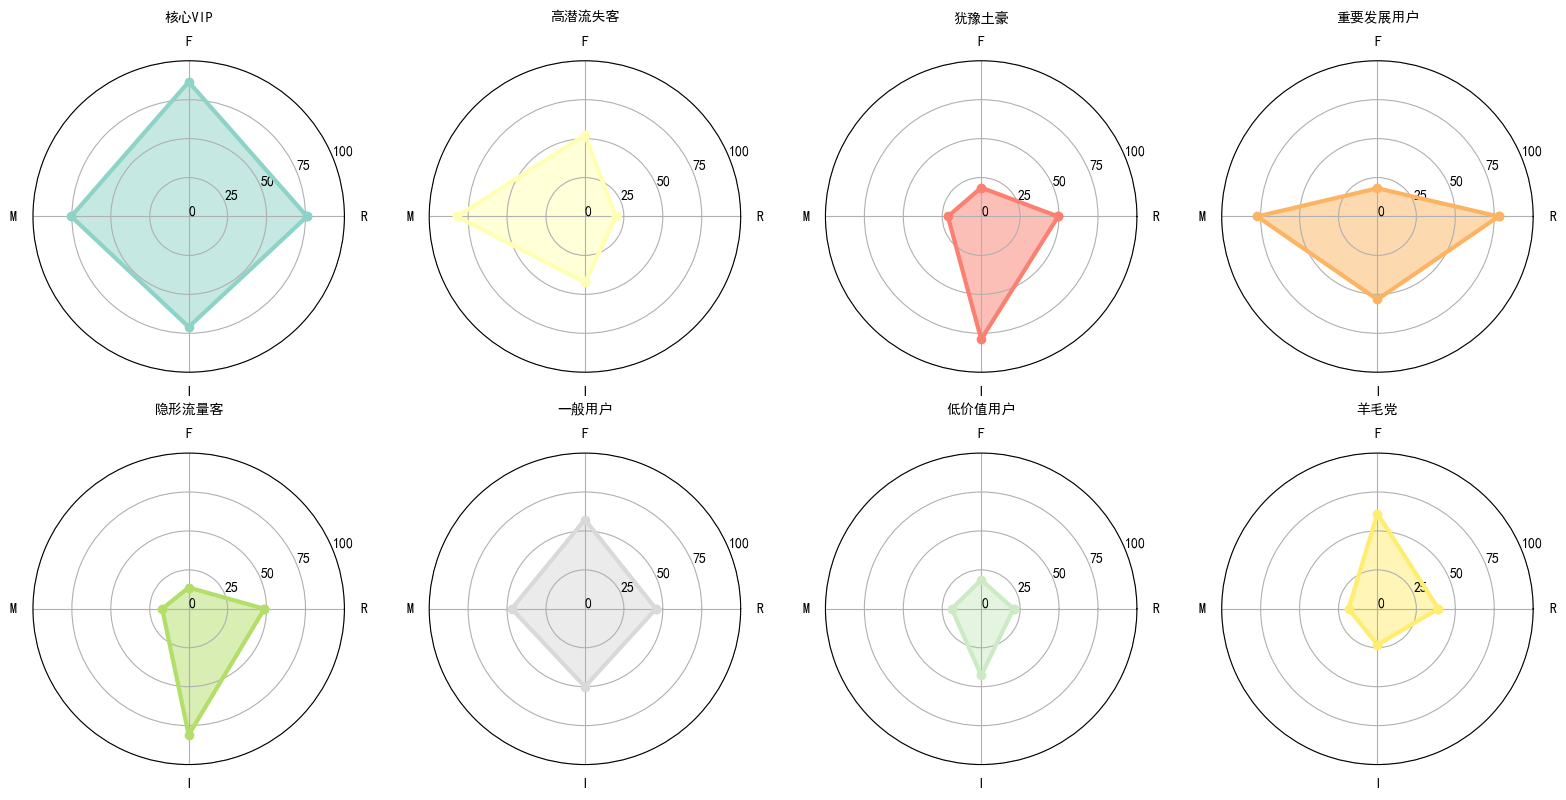

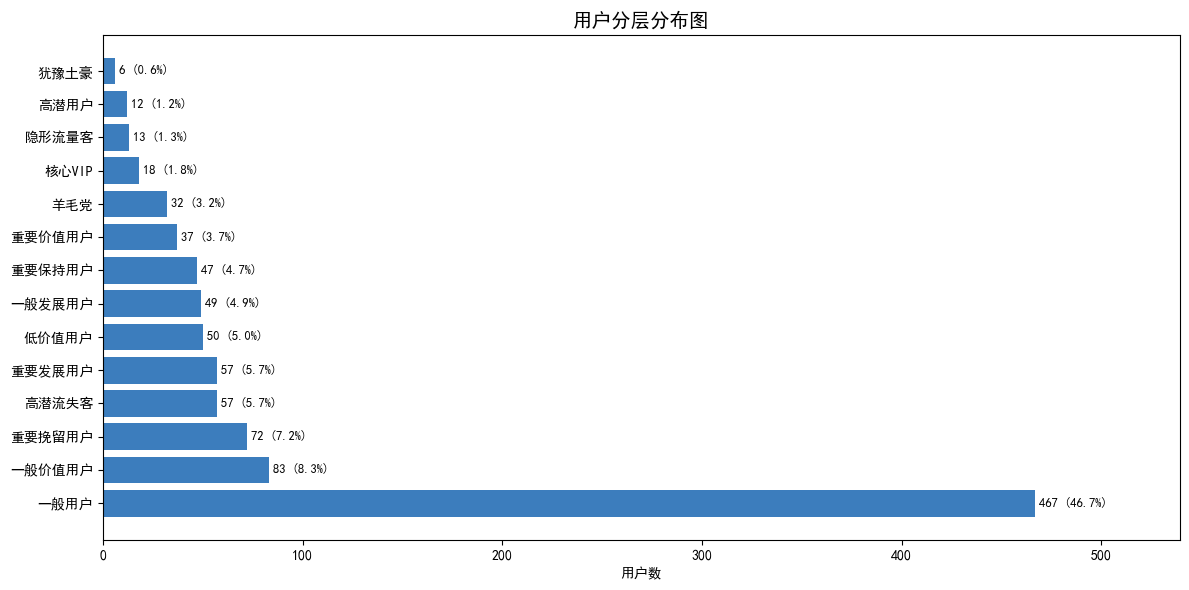

In [8]:
# 8. 生成用户画像可视化
def generate_segment_portrait(df, output_dir):
    
    print("第六部分：用户画像可视化\n")
    
    # 分层雷达图
#     segments = df['User_Segment'].unique()
    segments = ['核心VIP', '高潜流失客', '犹豫土豪', '重要发展用户', '隐形流量客', '一般用户','低价值用户', '羊毛党']
    metrics = ['R_Score', 'F_Score', 'M_Score', 'I_Score']
    
    segment_means = df.groupby('User_Segment')[metrics].mean().loc[segments]
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8), subplot_kw=dict(polar=True))
    axes = axes.flatten()
    
    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]
    
    colors = plt.cm.Set3(np.linspace(0, 1, len(segments)))
    
    for idx, segment in enumerate(segments[:8]):
        if idx >= len(axes):
            break
        ax = axes[idx]
        values = segment_means.loc[segment].tolist()
        values += values[:1]
        
        ax.plot(angles, values, 'o-', color=colors[idx], linewidth=3)
        ax.fill(angles, values, alpha=0.5, color=colors[idx])
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(['R', 'F', 'M', 'I'], fontsize=10)
        ax.set_title(segment, fontsize=10, pad=10)
        ax.set_ylim(0, 100)
        yticks = np.linspace(0, 100, 5)
        ax.set_yticks(yticks)
        ax.set_yticklabels([str(int(x)) for x in yticks], fontsize=10)

    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/分层雷达图.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # 分层分布柱状图
    segment_counts = df['User_Segment'].value_counts()
    
    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.barh(segment_counts.index, segment_counts.values, color='#0B5CAD', alpha=0.8)
    ax.set_xlabel('用户数')
    ax.set_title('用户分层分布图', fontsize=14)
      
    for bar, count in zip(bars, segment_counts.values):
        ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2, 
                f'{count} ({count/len(df)*100:.1f}%)', va='center', fontsize=9)
    ax.set_xlim(right=ax.get_xlim()[1] * 1.1)
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/用户分层分布图.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()


generate_segment_portrait(df, output_dir)


第七部分：ROI测算

【假设参数】
  总预算: 10000元
  优惠券成本: 10元/人
  平均客单价: 104元

【转化率假设】
  RFM前20%用户：自然转化率 20.0%，发券后 30.0%，边际提升 10.0%
  核心用户：自然转化率 25.0%，发券后 30.0%，边际提升 5.0%
  潜力用户：自然转化率 1.0%，发券后 20.0%，边际提升 19.0%

【方案A - 传统RFM策略】
  目标用户数: 200
  成本: 2000元 (预算使用率: 20.0%)
  收益: 2081元
  ROI: 4.0%

【方案B - 传统RFM策略精细化】
  核心用户: 37
  潜力用户: 72
  总目标用户数: 109
  实际成本: 1090元 (预算使用率: 10.9%)
  收益: 1616元
  ROI: 48.2%

【方案C - 优化RFM策略】
  核心用户: 18
  潜力用户: 75
  总目标用户数: 93
  实际成本: 930元 (预算使用率: 9.3%)
  收益: 1576元
  ROI: 69.5%


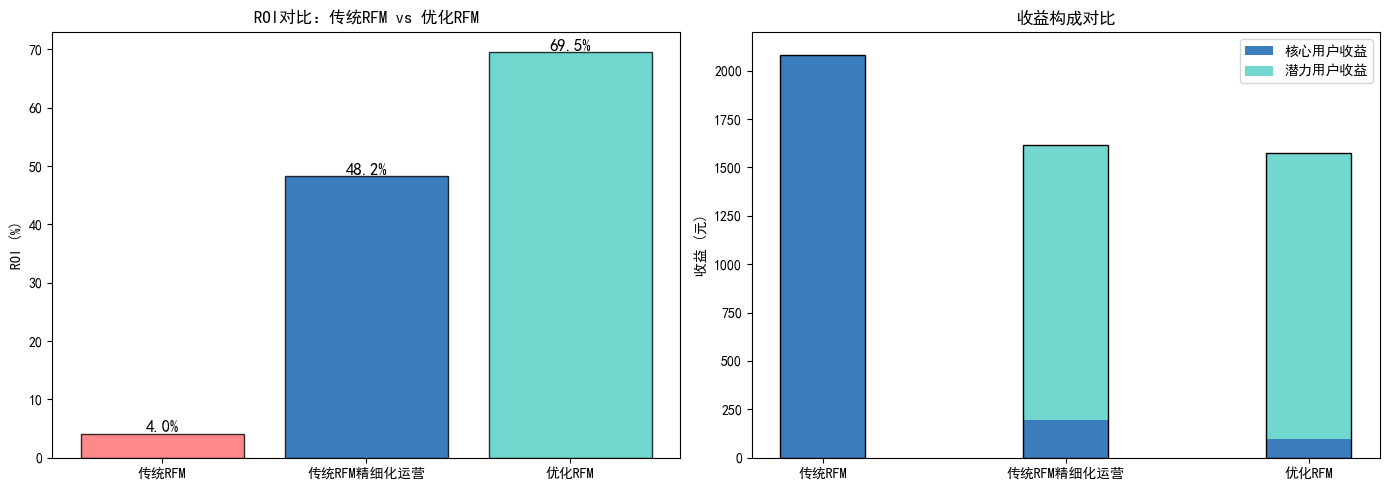

In [9]:
# 9. ROI测算
def calculate_roi(df, output_dir):

    print("\n" + "=" * 60)
    print("第七部分：ROI测算")
    print("=" * 60)
    
    # 相关参数假设
    total_budget = 10000          # 总预算（元）
    coupon_cost = 10               # 每张优惠券成本（元）
    aov = df['Average_Order_Value'].mean()  # 平均客单价（元）
    
    # 转化率假设
    general_natural = 0.02          # 一般用户无券自然转化率（不营销）
    core_natural = 0.25            # 核心用户无券自然转化率
    core_with_coupon = 0.30        # 核心用户发券后转化率
    potential_natural = 0.01       # 潜力用户无券自然转化率
    potential_with_coupon = 0.20   # 潜力用户发券后转化率
    rfm20_natural = 0.20            # rfm前百分二十用户无券自然转化率（介于核心和一般之间）
    rfm20_with_coupon = 0.30        # rfm前百分二十用户发券转化率（不超过核心用户）
    
    # 增量转化率
    core_lift = core_with_coupon - core_natural
    potential_lift = potential_with_coupon - potential_natural
    rfm20_lift = rfm20_with_coupon - rfm20_natural
    
    #方案A：传统RFM策略（给前百分之二十用户发券）
    top20_threshold = df['RFM_Score'].quantile(0.80)
    rfm_top20 = df[df['RFM_Score'] >= top20_threshold]        
    target_a_count = min(len(rfm_top20), total_budget // coupon_cost)       # 目标用户数不超预算
    cost_a = target_a_count * coupon_cost
    
    incremental_revenue_a = target_a_count * rfm20_lift * aov
    roi_a = (incremental_revenue_a - cost_a) / cost_a * 100 if cost_a > 0 else 0
    
    # 方案B：传统RFM策略精细化（核心+潜力）
    rfm_core_users = df[df['User_Segment'].isin(['重要价值用户'])]
    rfm_potential_users = df[df['User_Segment'].isin(['重要挽留用户'])]
    
    # 分配预算：优先潜力用户（60%预算），剩余给核心用户
    rfm_potential_count = min(len(rfm_potential_users), int(total_budget * 0.6 / coupon_cost))
    rfm_remaining_budget = total_budget - rfm_potential_count * coupon_cost
    rfm_core_count = min(len(rfm_core_users), rfm_remaining_budget // coupon_cost)
    target_b_count = rfm_core_count + rfm_potential_count
    cost_b = target_b_count * coupon_cost
    
    incremental_revenue_b = rfm_core_count * core_lift * aov + rfm_potential_count * potential_lift * aov
    roi_b = (incremental_revenue_b - cost_b) / cost_b * 100 if cost_b > 0 else 0
    
    # 方案C：优化RFM策略（核心+潜力）
    core_users = df[df['User_Segment'].isin(['核心VIP'])]
    potential_users = df[df['User_Segment'].isin(['犹豫土豪', '高潜用户', '高潜流失客'])]
    
    # 分配预算：优先潜力用户（60%预算），剩余给核心用户
    potential_count = min(len(potential_users), int(total_budget * 0.6 / coupon_cost))
    remaining_budget = total_budget - potential_count * coupon_cost
    core_count = min(len(core_users), remaining_budget // coupon_cost)
    target_c_count = core_count + potential_count
    cost_c = target_c_count * coupon_cost
    
    incremental_revenue_c = core_count * core_lift * aov + potential_count * potential_lift * aov
    roi_c = (incremental_revenue_c - cost_c) / cost_c * 100 if cost_c > 0 else 0
    
    # 输出结果 
    print(f"\n【假设参数】")
    print(f"  总预算: {total_budget}元")
    print(f"  优惠券成本: {coupon_cost}元/人")
    print(f"  平均客单价: {aov:.0f}元")
    
    print(f"\n【转化率假设】")
    print(f"  RFM前20%用户：自然转化率 {rfm20_natural*100:.1f}%，发券后 {rfm20_with_coupon*100:.1f}%，边际提升 {rfm20_lift*100:.1f}%")
    print(f"  核心用户：自然转化率 {core_natural*100:.1f}%，发券后 {core_with_coupon*100:.1f}%，边际提升 {core_lift*100:.1f}%")
    print(f"  潜力用户：自然转化率 {potential_natural*100:.1f}%，发券后 {potential_with_coupon*100:.1f}%，边际提升 {potential_lift*100:.1f}%")
    
    print(f"\n【方案A - 传统RFM策略】")
    print(f"  目标用户数: {target_a_count}")
    print(f"  成本: {cost_a}元 (预算使用率: {cost_a/total_budget*100:.1f}%)")
    print(f"  收益: {incremental_revenue_a:.0f}元")
    print(f"  ROI: {roi_a:.1f}%")
    
    print(f"\n【方案B - 传统RFM策略精细化】")
    print(f"  核心用户: {rfm_core_count}")
    print(f"  潜力用户: {rfm_potential_count}")
    print(f"  总目标用户数: {target_b_count}")
    print(f"  实际成本: {cost_b}元 (预算使用率: {cost_b/total_budget*100:.1f}%)")
    print(f"  收益: {incremental_revenue_b:.0f}元")
    print(f"  ROI: {roi_b:.1f}%")
    
    print(f"\n【方案C - 优化RFM策略】")
    print(f"  核心用户: {core_count}")
    print(f"  潜力用户: {potential_count}")
    print(f"  总目标用户数: {target_c_count}")
    print(f"  实际成本: {cost_c}元 (预算使用率: {cost_c/total_budget*100:.1f}%)")
    print(f"  收益: {incremental_revenue_c:.0f}元")
    print(f"  ROI: {roi_c:.1f}%")

    # ROI对比可视化
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # ROI对比
    strategies = ['传统RFM', '传统RFM精细化运营', '优化RFM']
    rois = [roi_a, roi_b, roi_c]
    colors = ['#FF6B6B', '#0B5CAD', '#4ECDC4']
    
    bars = axes[0].bar(strategies, rois, color=colors, alpha=0.8, edgecolor='black')
    axes[0].set_ylabel('ROI (%)')
    axes[0].set_title('ROI对比：传统RFM vs 优化RFM', fontsize=12)
    for bar, roi in zip(bars, rois):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
                    f'{roi:.1f}%', ha='center', fontsize=12, fontweight='bold')
    
    # 收益构成对比
    x = np.arange(3)
    width = 0.35
    
    core_marginal = [incremental_revenue_a, rfm_core_count * core_lift * aov, core_count * core_lift * aov]
    potential_marginal = [0, rfm_potential_count * potential_lift * aov, potential_count * potential_lift * aov]
    core_arr = np.array(core_marginal)
    pot_arr = np.array(potential_marginal)
    total_marginal = core_arr + pot_arr
    
    axes[1].bar(x, core_marginal, width, label='核心用户收益', color='#0B5CAD', alpha=0.8)
    axes[1].bar(x, potential_marginal, width, bottom=core_marginal, label='潜力用户收益', color='#4ECDC4', alpha=0.8)
    axes[1].bar(x, total_marginal, width, color='none', edgecolor='black')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(strategies)
    axes[1].set_ylim(0, 2200)
    axes[1].set_ylabel('收益 (元)')
    axes[1].set_title('收益构成对比', fontsize=12)
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/ROI和收益构成对比图.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

calculate_roi(df, output_dir)